In [2]:
from sklearn.metrics import roc_auc_score, roc_curve, auc

In [31]:
import pandas as pd
import numpy as np

simmap_file = '../ped-sim/refined_mf.simmap'


%load_ext autoreload
%autoreload 2

from sex_inference_analysis import main, do_data_analysis

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:

import seaborn as sns
import matplotlib.pyplot as plt

def make_hist_plot(female_lods, male_lods):
    df = pd.DataFrame({
        'value': np.concatenate([female_lods, male_lods]),
        'dataset': ['F'] * len(male_lods) + ['M'] * len(male_lods)
    })
    
    # Plot
    sns.histplot(
        data=df, 
        x='value', 
        hue='dataset', 
        palette={'F': 'salmon', 'M': 'skyblue'},
        alpha=0.5,
        bins=30
    )
    
    plt.title(f'Grandparent Sex Inference')
    
    plt.show()



In [37]:
def get_lods(input_file_for_analysis, final_results_file, params_for_data_analysis):
    
    results_df = do_data_analysis(input_file=input_file_for_analysis,
                     output_file=final_results_file,
                     simmap=simmap_file,
                     details=params_for_data_analysis
                     )
    
    # results_df = pd.read_csv(final_results_file, sep='\t')

    male_results = results_df[results_df['pedigree_id'].str.contains(r'^male-')]
    female_results = results_df[results_df['pedigree_id'].str.contains(r'^female-')]

    female_lods = list(female_results['LOD'].astype(float))
    male_lods = list(male_results['LOD'].astype(float))
        
    return female_lods, male_lods


def get_auc_from_lods(female_lods, male_lods):
    y_true = [1 for _ in range(len(list(female_lods)))] + [0 for _ in range(len(list(male_lods)))]
    y_score = list(female_lods) + list(male_lods)

    auc_score = roc_auc_score(y_true, y_score)

    return auc_score

In [33]:
def get_results_given_params(input_files_for_data_analysis, output_file_root_name, all_params):
    results = {}

    for index, (param_name, params) in enumerate(all_params.items()):
        print(index, param_name, params)
        final_results = f'{output_file_root_name}_{size}_{param_name}.csv'
        female_lods, male_lods = get_lods(input_file_for_analysis=input_files_for_data_analysis, 
                                            final_results_file=final_results, 
                                            params_for_data_analysis=params)
        
        auc = get_auc_from_lods(female_lods, male_lods)
        
        results[param_name] = {
            'auc': auc,
            'female_lods':female_lods,
            'male_lods':male_lods
        }
        
    for param_name, params in all_params.items():
        print(f'{param_name}: {results[param_name]["auc"]}')
        print('; '.join(f'{name}={value}' for name, value in params.items()))
        print()
        
    return results

In [13]:
size = 200
input_file = f'../ped-sim/outputs/gp-sex/gp-sex-{size}.seg'

output_file_from_main = f'results_with_transformed_data_{size}.csv'

main(input_file=input_file, map_file=simmap_file, output_file=output_file_from_main)

male-gparent1
male-gparent2
male-gparent3
male-gparent4
male-gparent5
male-gparent6
male-gparent7
male-gparent8
male-gparent9
male-gparent10
male-gparent11
male-gparent12
male-gparent13
male-gparent14
male-gparent15
male-gparent16
male-gparent17
male-gparent18
male-gparent19
male-gparent20
male-gparent21
male-gparent22
male-gparent23
male-gparent24
male-gparent25
male-gparent26
male-gparent27
male-gparent28
male-gparent29
male-gparent30
male-gparent31
male-gparent32
male-gparent33
male-gparent34
male-gparent35
male-gparent36
male-gparent37
male-gparent38
male-gparent39
male-gparent40
male-gparent41
male-gparent42
male-gparent43
male-gparent44
male-gparent45
male-gparent46
male-gparent47
male-gparent48
male-gparent49
male-gparent50
male-gparent51
male-gparent52
male-gparent53
male-gparent54
male-gparent55
male-gparent56
male-gparent57
male-gparent58
male-gparent59
male-gparent60
male-gparent61
male-gparent62
male-gparent63
male-gparent64
male-gparent65
male-gparent66
male-gparent67
male

In [39]:
input_files_for_data_analysis = output_file_from_main

analysis_count = 200

all_params = {
    "keep_dups_no_gaps": {"drop_duplicates": False, "count_gaps":False, "analysis_count":analysis_count},
    "no_dups_no_gaps": {"drop_duplicates": True, "count_gaps":False, "analysis_count":analysis_count},
    "keep_dups_gaps_only_overlaps_small_window": {"drop_duplicates": True, "count_gaps":False, "only_count_overlapping_ends": True, "analysis_count": analysis_count, "window_size": 50},
    "keep_dups_gaps_only_overlaps": {"drop_duplicates": True, "count_gaps":False, "only_count_overlapping_ends": True, "analysis_count": analysis_count},
    # "keep_dups_gaps": {"drop_duplicates": False, "count_gaps":True, "analysis_count":analysis_count},
    # "no_dups_gaps": {"drop_duplicates": True, "count_gaps":True, "analysis_count":analysis_count}
} 

results_dups_and_gaps = get_results_given_params(input_files_for_data_analysis, f'10-6-25-final_results_size_{analysis_count}_', all_params)


0 keep_dups_no_gaps {'drop_duplicates': False, 'count_gaps': False, 'analysis_count': 200}
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
1 no_dups_no_gaps {'drop_duplicates': True, 'count_gaps': False, 'analysis_count': 200}
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
The start is greater than the end of the segment
2 keep_dups_gaps_only_overlaps_small_window {'drop_duplicates': True, 'count_gaps': False, 'only_count_overlapping_ends': True, 'analysis_count': 200, 'window_size': 50}
3 keep_dups_gaps_only_overlaps {'drop_duplicates': True, 'count

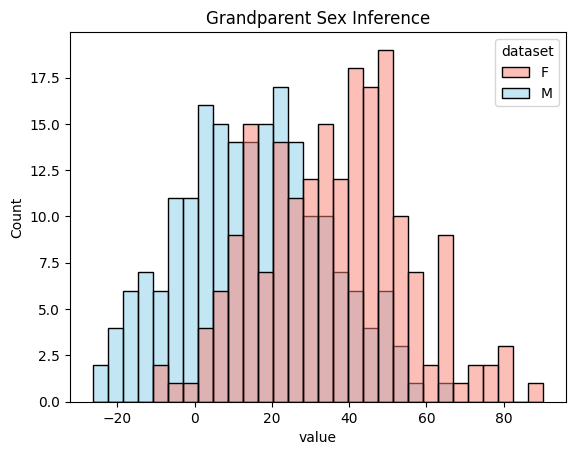

In [40]:
data = results_dups_and_gaps['keep_dups_gaps_only_overlaps']
f = data['female_lods']
m = data['male_lods']
make_hist_plot(f,m)


### Results

keep_dups_no_gaps: 0.7867564534231202
drop_duplicates=False; count_gaps=False; analysis_count=99

no_dups_no_gaps: 0.7602285481073361
drop_duplicates=True; count_gaps=False; analysis_count=99

keep_dups_gaps_only_overlaps_small_window: 0.8107335986123866
drop_duplicates=True; count_gaps=False; only_count_overlapping_ends=True; analysis_count=99; window_size=50

#### Results size 200

keep_dups_no_gaps: 0.7591
drop_duplicates=False; count_gaps=False; analysis_count=200

no_dups_no_gaps: 0.724975
drop_duplicates=True; count_gaps=False; analysis_count=200

keep_dups_gaps_only_overlaps_small_window: 0.78355
drop_duplicates=True; count_gaps=False; only_count_overlapping_ends=True; analysis_count=200; window_size=50

keep_dups_gaps_only_overlaps: 0.7819500000000001
drop_duplicates=True; count_gaps=False; only_count_overlapping_ends=True; analysis_count=200